In [1]:
%load_ext autoreload 
%autoreload 2

import os, sys
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../.."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(os.path.join(os.getcwd(), ".."))

import math
import numpy as np
import pandas as pd
from numpy import array
from numpy import array, arange, abs as np_abs
from numpy.fft import rfft, rfftfreq
from math import sin, pi
from scipy import signal
import matplotlib.pyplot as plt
import plotly.graph_objects as go

import importlib
import model as md
import view as vw

importlib.reload(md)
importlib.reload(vw)

c:\Users\Артем\Desktop\Вуз\Аспирантура\Диссертация\Алгоритм\Relaxation_frequency_phase_algorithm\notebooks\Phase_methods_analytics\Local_analysis\..


<module 'view' from 'c:\\Users\\Артем\\Desktop\\Вуз\\Аспирантура\\Диссертация\\Алгоритм\\Relaxation_frequency_phase_algorithm\\view\\__init__.py'>

In [2]:
def plot_for_one_F(F_range,phases_arrays, phase_diff_arrays, title=""):
    fig = plt.figure(figsize=(8, 5))
    gs = fig.add_gridspec(2, 1)
    front = 12

    ax1 = fig.add_subplot(gs[0, 0])
    for i in range(0,len(F_range),1):
        label_name = F_range[i]
        ax1.plot(
            phases_arrays[i],
            np.abs(phase_diff_arrays[i]),
            label=label_name,
            linewidth=2
        )

    ax1.set_xlabel('Phase shift, °', fontsize=front)
    ax1.set_ylabel('Phase measurement deviation, °', fontsize=front)
    ax1.tick_params(axis='both', labelsize=front)
    ax1.grid(True)
    ax1.legend(fontsize=10)

    ax1.set_title(title, fontsize=front + 2)
    plt.tight_layout()
    plt.show()

In [3]:
def variate_F_phase(phase_method):
    F_range=[]
    phases_arrays = []
    phase_diff_arrays = []

    for F in range(int(400e3), int(420e3), int(10e3)):
        F_range.append(F)
        print(F)
        currant_phases=[]
        current_difs=[]
        for phase in range(1, 180, 1):
            duration = 100e-6
            fs = F * 100

            t = np.linspace(0, duration, int(duration * fs))
            U = md.generate_sin(t, F, 2)
            I = md.generate_sin(t, F, 2, phase)

            # Вызов метода напрямую
            phase_d = phase_method(t, U, I, F)

            currant_phases.append(phase)
            current_difs.append(abs(phase_d)-abs(phase))
            
        print(current_difs)
        phases_arrays.append(currant_phases)
        phase_diff_arrays.append(current_difs)

    return F_range,phases_arrays, phase_diff_arrays

400000
[np.float64(-1.2257999076781267e-05), np.float64(2.0344819717355023e-05), np.float64(8.138444126171152e-06), np.float64(2.050485255367107e-05), np.float64(-2.618601825421507e-05), np.float64(4.351860707352273e-06), np.float64(-1.5907780233526125e-05), np.float64(1.2978146859410344e-05), np.float64(1.914973578642787e-05), np.float64(1.169272181122949e-05), np.float64(-0.19735073691468763), np.float64(-3.0685005915742636e-05), np.float64(1.472043984485083e-05), np.float64(-3.197043096392349e-05), np.float64(-3.1167685603961104e-05), np.float64(-3.821171161000336e-05), np.float64(-6.847856717229206e-06), np.float64(-3.454128105673249e-05), np.float64(-4.6128174695070356e-05), np.float64(-2.095913930588722e-05), np.float64(-3.316551489618291e-05), np.float64(-3.979655292951634e-05), np.float64(-4.60146030079045e-05), np.float64(-6.751320784559312e-05), np.float64(-4.06922205797855e-05), np.float64(-0.00010018571835956891), np.float64(-6.758289956465546e-05), np.float64(-7.5039913536

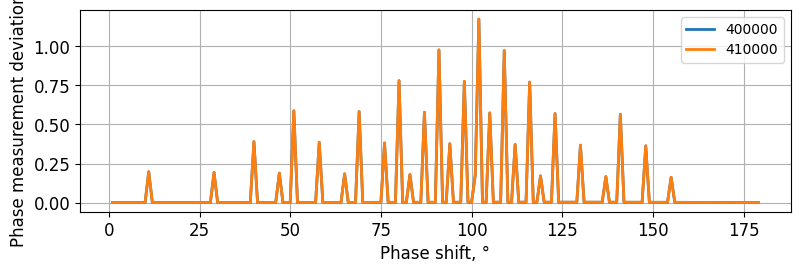

In [4]:
F_range,phases_arrays, phase_diff_arrays=variate_F_phase(md.get_phase_XCOR)
plot_for_one_F(F_range,phases_arrays, phase_diff_arrays)

In [5]:
def average_mse(arrays):
    """
    arrays: список numpy-массивов одинаковой длины
    """
    first = arrays[0]
    mses = []

    for arr in arrays[1:]:
        mse = np.mean((first - arr) ** 2)
        mses.append(mse)

    return np.mean(mses)

arrays = np.array(phase_diff_arrays)

result = average_mse(arrays)
print(result)

6.084870382705819e-08
